In [1]:
from typing import Sequence, List, Tuple
import math

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse


def _ellipse_palette() -> List[str]:
    return [
        "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
        "#a65628", "#f781bf", "#17becf", "#bcbd22", "#666666",
    ]


def compute_c_values(P: Sequence[float]) -> List[float]:
    """
    Compute [C_t(P)] for t = 1, ..., k-1 where P = (p_1, ..., p_k).

    C_t(P) = sum_{i=1}^t p_i^2 - (1/t)(sum_{i=1}^t p_i)^2
             + sum_{i=t+1}^k p_i^2 - (1/(k-t))(sum_{i=t+1}^k p_i)^2
    """
    k = len(P)
    if k < 2:
        raise ValueError("P must contain at least 2 elements.")

    prefix = [0.0]
    prefix_sq = [0.0]
    for x in P:
        x = float(x)
        prefix.append(prefix[-1] + x)
        prefix_sq.append(prefix_sq[-1] + x * x)

    total = prefix[k]
    total_sq = prefix_sq[k]

    c_values = []
    for t in range(1, k):
        left_sum = prefix[t]
        left_sq_sum = prefix_sq[t]
        right_sum = total - left_sum
        right_sq_sum = total_sq - left_sq_sum

        c_t = (
            left_sq_sum - (left_sum * left_sum) / t
            + right_sq_sum - (right_sum * right_sum) / (k - t)
        )
        c_values.append(c_t)

    return c_values


def compute_centers(P: Sequence[float]) -> List[Tuple[float, float]]:
    """Compute centers (center_left, center_right) for t = 1, ..., k-1."""
    k = len(P)
    if k < 2:
        raise ValueError("P must contain at least 2 elements.")

    prefix = [0.0]
    for x in P:
        prefix.append(prefix[-1] + float(x))

    total = prefix[k]
    centers = []
    for t in range(1, k):
        left_sum = prefix[t]
        right_sum = total - left_sum
        centers.append((left_sum / t, right_sum / (k - t)))

    return centers


def euclidean_distance(p: Sequence[float], q: Sequence[float]) -> float:
    if len(p) != len(q):
        raise ValueError("Points must have the same dimension.")
    return sum((pi - qi) ** 2 for pi, qi in zip(p, q)) ** 0.5


def plot_partition_ellipses(P: Sequence[float], Delta: float, ax=None, alpha: float = 0.14):
    """
    Plot ellipses defined by

        t * (x - c_left)^2 + (k-t) * (y - c_right)^2 <= Delta - C_t(P)

    for t = 1, ..., k-1.
    """
    k = len(P)
    if k < 2:
        raise ValueError("P must contain at least 2 elements.")

    Delta = float(Delta)
    c_values = compute_c_values(P)
    centers = compute_centers(P)

    created_fig = False
    if ax is None:
        created_fig = True
        fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

    palette = _ellipse_palette()

    x_min = float("inf")
    x_max = float("-inf")
    y_min = float("inf")
    y_max = float("-inf")

    plotted_any = False

    for idx, (t, c_t, center) in enumerate(zip(range(1, k), c_values, centers), start=1):
        radius_sq = Delta - c_t
        if radius_sq < 0:
            continue

        plotted_any = True
        c_left, c_right = center
        a = (radius_sq / t) ** 0.5
        b = (radius_sq / (k - t)) ** 0.5
        color = palette[(idx - 1) % len(palette)]

        ax.add_patch(Ellipse((c_left, c_right), 2 * a, 2 * b, facecolor=color, edgecolor="none", alpha=alpha, zorder=1))
        ax.add_patch(Ellipse((c_left, c_right), 2 * a, 2 * b, facecolor="none", edgecolor=color, linewidth=1.0, alpha=0.95, zorder=2))

        ax.scatter(c_left, c_right, color=color, s=20, edgecolors="black", linewidths=0.5, zorder=3)

        label_dx = 0.06 * max(a, 1e-12)
        label_dy = 0.06 * max(b, 1e-12)
        ax.text(
            c_left + label_dx,
            c_right + label_dy,
            f"E_{t}",
            color=color,
            fontsize=6,
            weight="bold",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.0, pad=1.2),
            zorder=4,
        )

        x_min = min(x_min, c_left - a)
        x_max = max(x_max, c_left + a)
        y_min = min(y_min, c_right - b)
        y_max = max(y_max, c_right + b)

    if not plotted_any:
        raise ValueError("No ellipse satisfies Delta - C_t(P) >= 0 for the given input.")

    x_span = max(x_max - x_min, 1e-12)
    y_span = max(y_max - y_min, 1e-12)
    x_pad = 0.12 * x_span
    y_pad = 0.12 * y_span

    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.set_aspect("equal", adjustable="box")
    ax.ticklabel_format(style="sci", axis="both", scilimits=(-2, 2))
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("")

    if created_fig:
        fig.tight_layout()

    return ax


def plot_partition_lines(
    P: Sequence[float],
    ax=None,
    x_range=None,
    linewidth: float = 1.2,
    linestyle: str = "--",
    alpha: float = 0.9,
    color=None,
):
    """
    Plot k-1 lines where the t-th line has direction vector (1, -t/(k-t)).
    Each line passes through the t-th center.

    Parameters
    ----------
    color : str or None
        If given, all lines are drawn in this color. If None (default),
        each line uses the matching ellipse color from the palette.
    """
    k = len(P)
    if k < 2:
        raise ValueError("P must contain at least 2 elements.")

    centers = compute_centers(P)
    palette = _ellipse_palette()

    created_fig = False
    if ax is None:
        created_fig = True
        fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

    if x_range is not None:
        x0, x1 = float(x_range[0]), float(x_range[1])
    else:
        has_existing_limits = (ax.get_xlim() != (0.0, 1.0))
        if has_existing_limits:
            x0, x1 = ax.get_xlim()
        else:
            xs = [c[0] for c in centers]
            x_min = min(xs)
            x_max = max(xs)
            x_span = max(x_max - x_min, 1e-12)
            x_pad = 0.6 * x_span
            x0, x1 = x_min - x_pad, x_max + x_pad

    for t, (cx, cy) in enumerate(centers, start=1):
        m = -t / (k - t)
        y0 = cy + m * (x0 - cx)
        y1 = cy + m * (x1 - cx)
        line_color = color if color is not None else palette[(t - 1) % len(palette)]
        ax.plot([x0, x1], [y0, y1], color=line_color, linewidth=linewidth, linestyle=linestyle, alpha=alpha, zorder=0)

    if created_fig:
        ax.ticklabel_format(style="sci", axis="both", scilimits=(-2, 2))
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        fig.tight_layout()

    return ax


def _angle_alignment(angle: float):
    """Return (ha, va) text alignment suitable for a label placed at the given angle."""
    cos_a = math.cos(angle)
    sin_a = math.sin(angle)
    ha = "left" if cos_a > 0.1 else ("right" if cos_a < -0.1 else "center")
    va = "bottom" if sin_a > 0.1 else ("top" if sin_a < -0.1 else "center")
    return ha, va


def plot_multi_partition_ellipses(
    partitions: List[Tuple[Sequence[float], float]],
    ax=None,
    alpha: float = 0.14,
    partition_labels: List[str] = None,
    label_offset: float = 1.12,
):
    """
    Plot ellipses for multiple partitions P_1, ..., P_m on a single axes.
    All ellipses that belong to the same P_i share one color.

    Each partition's labels are placed outside the ellipse boundary at a unique
    angle (evenly spaced around the full circle), so labels stay separated even
    when ellipse centers overlap.

    Parameters
    ----------
    partitions : list of (P, Delta) tuples
    ax : matplotlib Axes, optional
    alpha : float
        Fill transparency for each ellipse.
    partition_labels : list of str, optional
        Legend labels. Defaults to "$P_1$", "$P_2$", ...
    label_offset : float
        Multiplier beyond the ellipse edge where labels are placed (> 1).
        Increase to push labels further outside when they still overlap.
    """
    created_fig = False
    if ax is None:
        created_fig = True
        fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

    palette = _ellipse_palette()
    n_partitions = len(partitions)

    if partition_labels is None:
        partition_labels = [f"$Q_{{{i + 1}}}$" for i in range(n_partitions)]

    x_min = float("inf")
    x_max = float("-inf")
    y_min = float("inf")
    y_max = float("-inf")

    legend_handles = []

    for pi_idx, (P, Delta) in enumerate(partitions):
        k = len(P)
        if k < 2:
            raise ValueError(f"Partition {pi_idx + 1}: P must contain at least 2 elements.")

        Delta = float(Delta)
        c_values = compute_c_values(P)
        centers = compute_centers(P)
        color = palette[pi_idx % len(palette)]

        # Evenly spread angles, starting at 45° so no label sits on an axis.
        angle = math.pi / 4 + (2 * math.pi * pi_idx) / max(n_partitions, 1)
        ha, va = _angle_alignment(angle)

        plotted_any = False
        legend_patch = None

        for idx, (t, c_t, center) in enumerate(zip(range(1, k), c_values, centers), start=1):
            radius_sq = Delta - c_t
            if radius_sq < 0:
                continue

            plotted_any = True
            c_left, c_right = center
            a = (radius_sq / t) ** 0.5
            b = (radius_sq / (k - t)) ** 0.5

            ax.add_patch(Ellipse((c_left, c_right), 2 * a, 2 * b, facecolor=color, edgecolor="none", alpha=alpha, zorder=1))
            outline = Ellipse((c_left, c_right), 2 * a, 2 * b, facecolor="none", edgecolor=color, linewidth=1.0, alpha=0.95, zorder=2)
            ax.add_patch(outline)
            if legend_patch is None:
                legend_patch = outline

            ax.scatter(c_left, c_right, color=color, s=20, edgecolors="black", linewidths=0.5, zorder=3)

            # Place the label at the ellipse boundary (scaled by label_offset) in
            # this partition's unique direction.
            lx = c_left  + label_offset * a * math.cos(angle)
            ly = c_right + label_offset * b * math.sin(angle)
            ax.annotate(
                f"$E_{{{t}}}$",
                xy=(c_left + a * math.cos(angle), c_right + b * math.sin(angle)),  # ellipse edge
                xytext=(lx, ly),
                color=color,
                fontsize=9,
                weight="bold",
                ha=ha,
                va=va,
                # bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
                zorder=5,
            )

            x_min = min(x_min, c_left - a)
            x_max = max(x_max, c_left + a)
            y_min = min(y_min, c_right - b)
            y_max = max(y_max, c_right + b)

        if not plotted_any:
            raise ValueError(f"Partition {pi_idx + 1}: no ellipse satisfies Delta - C_t(P) >= 0.")

        legend_patch.set_label(partition_labels[pi_idx])
        legend_handles.append(legend_patch)

    x_span = max(x_max - x_min, 1e-12)
    y_span = max(y_max - y_min, 1e-12)
    x_pad = 0.18 * x_span
    y_pad = 0.18 * y_span

    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.set_aspect("equal", adjustable="box")
    ax.ticklabel_format(style="sci", axis="both", scilimits=(-2, 2))
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(handles=legend_handles, loc="best", fontsize=8)

    if created_fig:
        fig.tight_layout()

    return ax


In [2]:
my_c_values = compute_c_values([-10*1e-5, 50*1e-5, 20*1e-5, -70*1e-5, 30*1e-5, -20*1e-5])

print("C values:", my_c_values)

C values: [9.080000000000001e-07, 8.000000000000002e-07, 6.800000000000002e-07, 9.125000000000003e-07, 8.720000000000002e-07]


In [3]:
my_centers = compute_centers([-10*1e-5, 50*1e-5, 25*1e-5, -4*1e-5, 30*1e-5, -90*1e-5])

print("Centers:", my_centers)

Centers: [(-0.0001, 2.1999999999999986e-05), (0.0002, -9.750000000000003e-05), (0.00021666666666666666, -0.00021333333333333336), (0.0001525, -0.00030000000000000003), (0.000182, -0.0009000000000000001)]


In [4]:
euclidean_distance(my_centers[0], my_centers[-1])

0.0009641618121456585

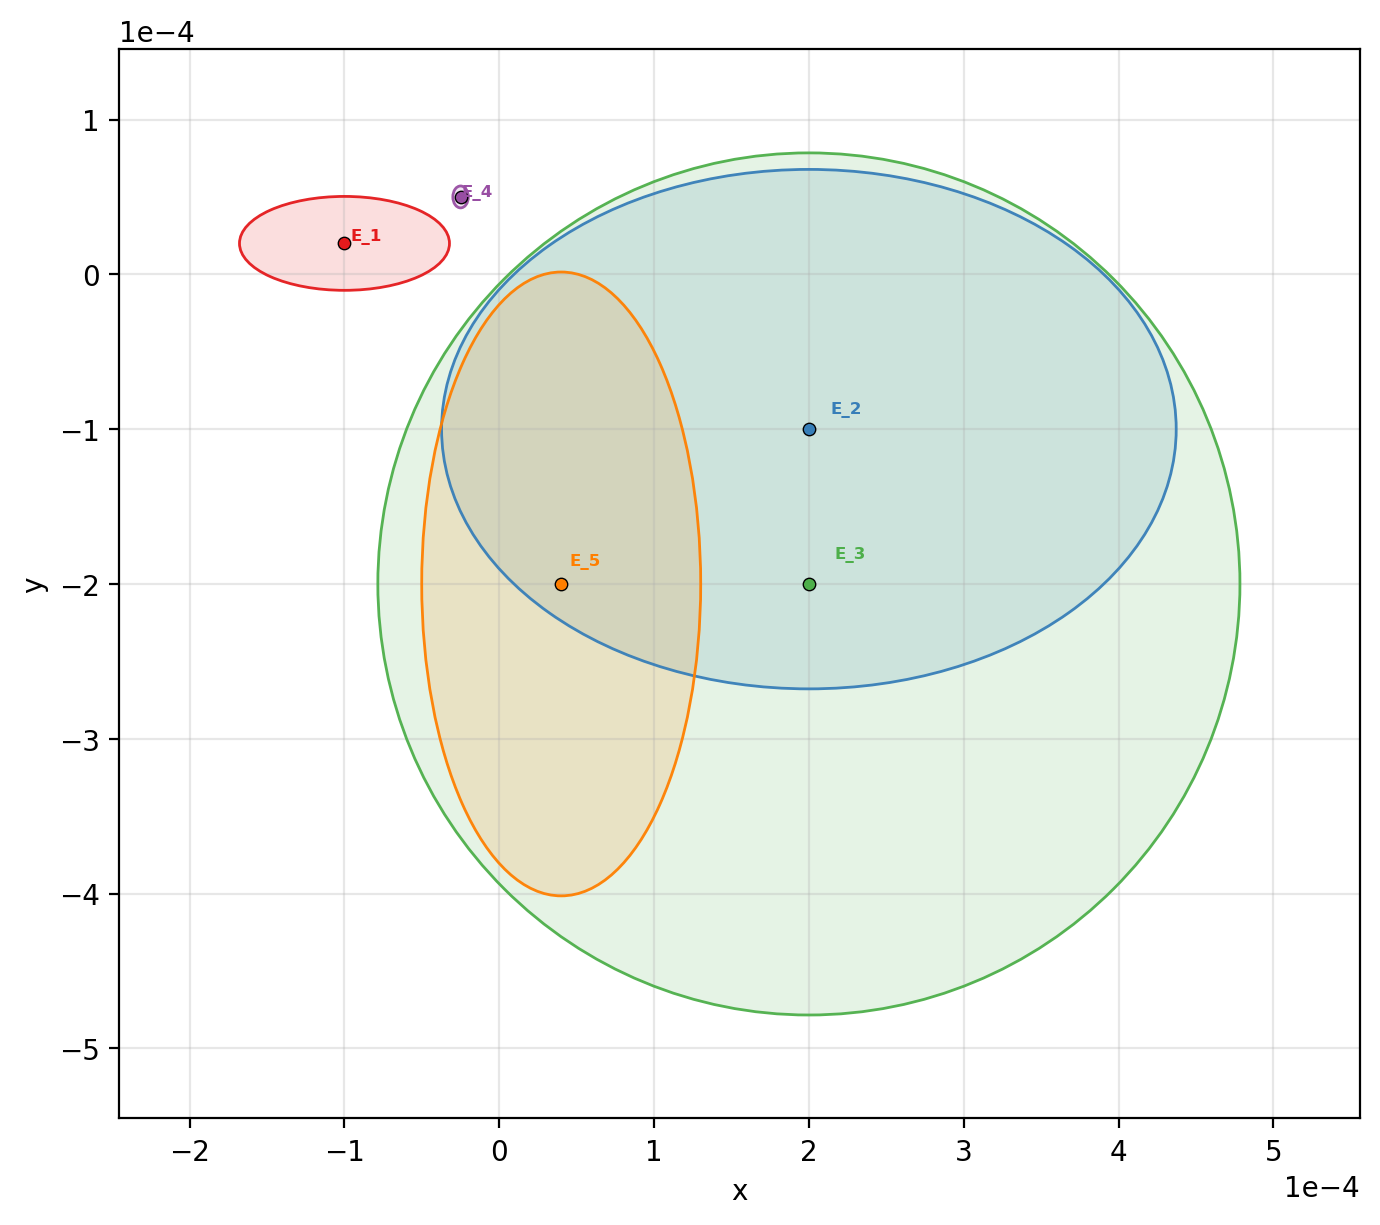

In [5]:
P = [-10*1e-5, 50*1e-5, 20*1e-5, -70*1e-5, 30*1e-5, -20*1e-5]
Delta = max(compute_c_values(P)) + 1e-10
plot_partition_ellipses(P, Delta)
plt.show()

In [6]:
def compute_point_on_line(a: float, k:int ):
    a_list = []
    for t in range(1,k):
        a_t = a * ((1+ 1/(k-1))/(t + t**2/(k-t)))**0.5
        a_list.append(a_t)
    return a_list

def compute_p_from_a(a_list):
    p_list = []
    for i in range(len(a_list)):
        a_t = a_list[i]
        t = i + 1
        p_t = t*a_t - (t-1)*a_list[i-1] if i > 0 else t*a_t
        p_list.append(p_t)
    p_last = -sum(p_list)
    p_list.append(p_last)
    return [p_t for p_t in p_list]

In [7]:
mya_list = compute_point_on_line(1.0, 6)
myp_list = compute_p_from_a(mya_list)

In [8]:
print("a values:", mya_list)
print("p values:", myp_list)

a values: [1.0, 0.6324555320336759, 0.4472135954999579, 0.31622776601683794, 0.2]
p values: [1.0, 0.26491106406735176, 0.07672972243252207, -0.07672972243252207, -0.26491106406735176, -1.0]


In [9]:
compute_c_values(myp_list)

[0.9521306443397368,
 0.9521306443397367,
 0.9521306443397367,
 0.9521306443397368,
 0.9521306443397368]

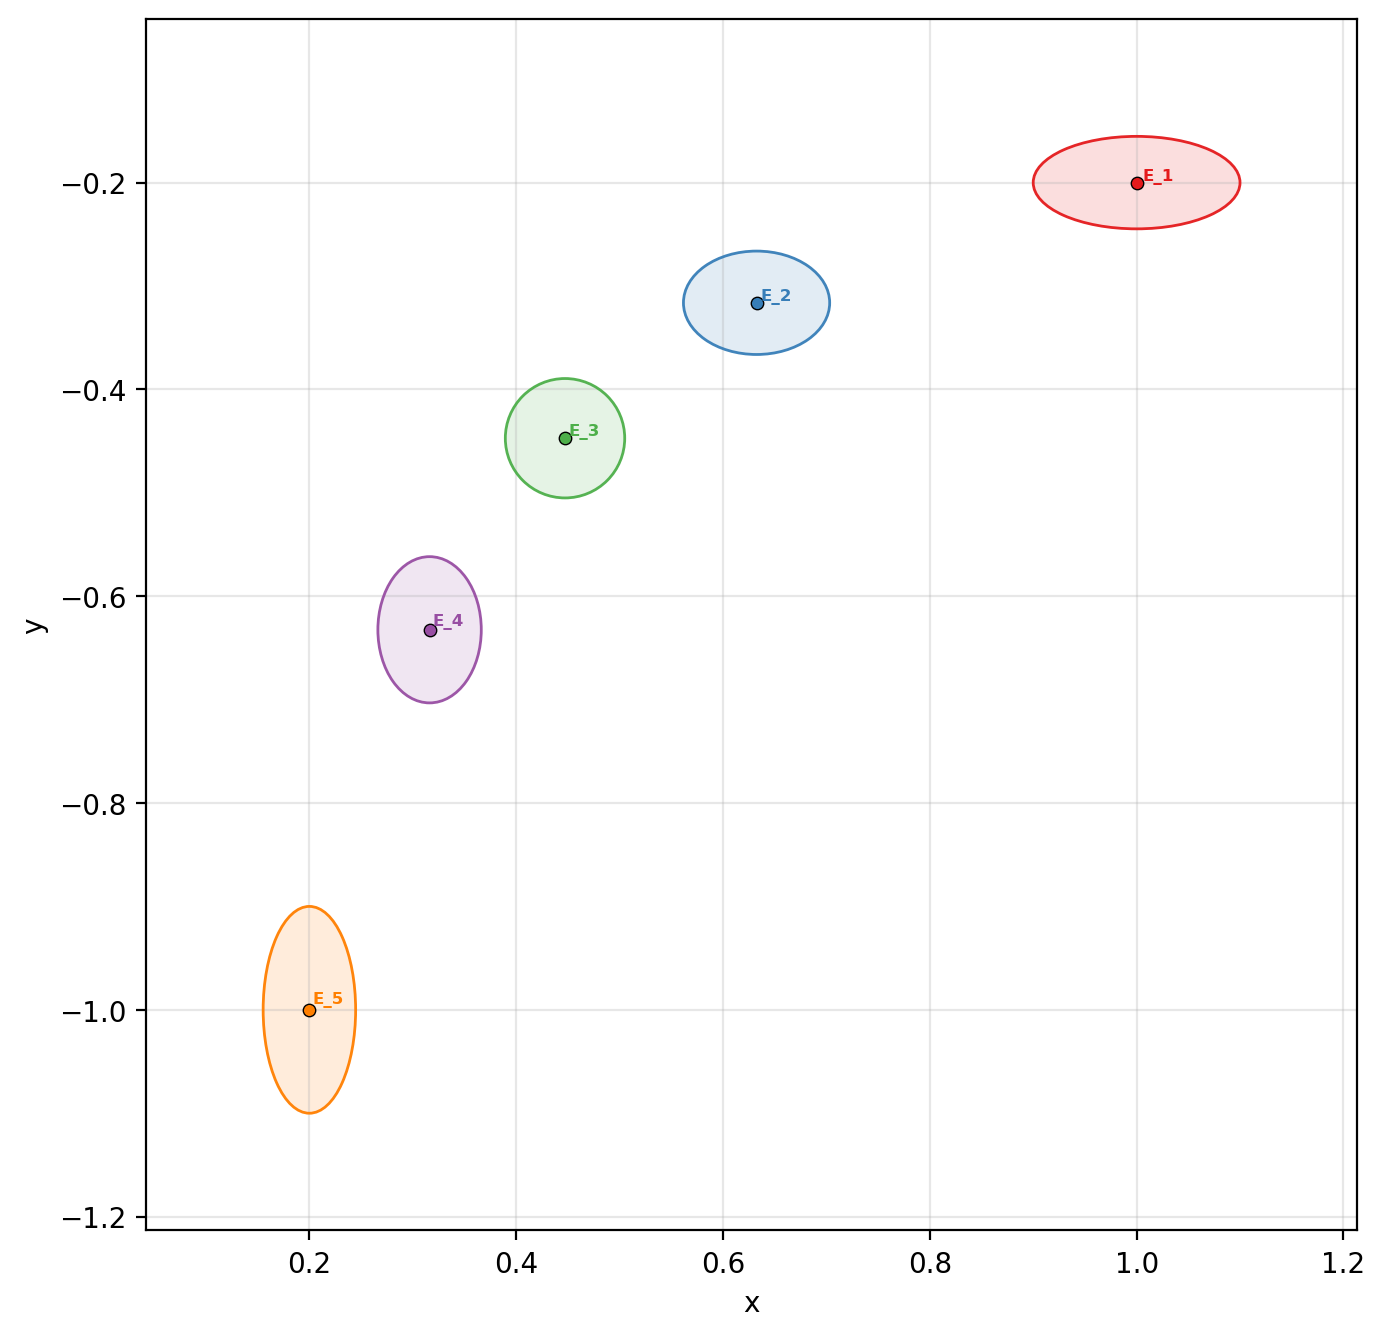

In [10]:
P = myp_list
Delta = max(compute_c_values(P)) + 0.01
plot_partition_ellipses(P, Delta)
plt.show()

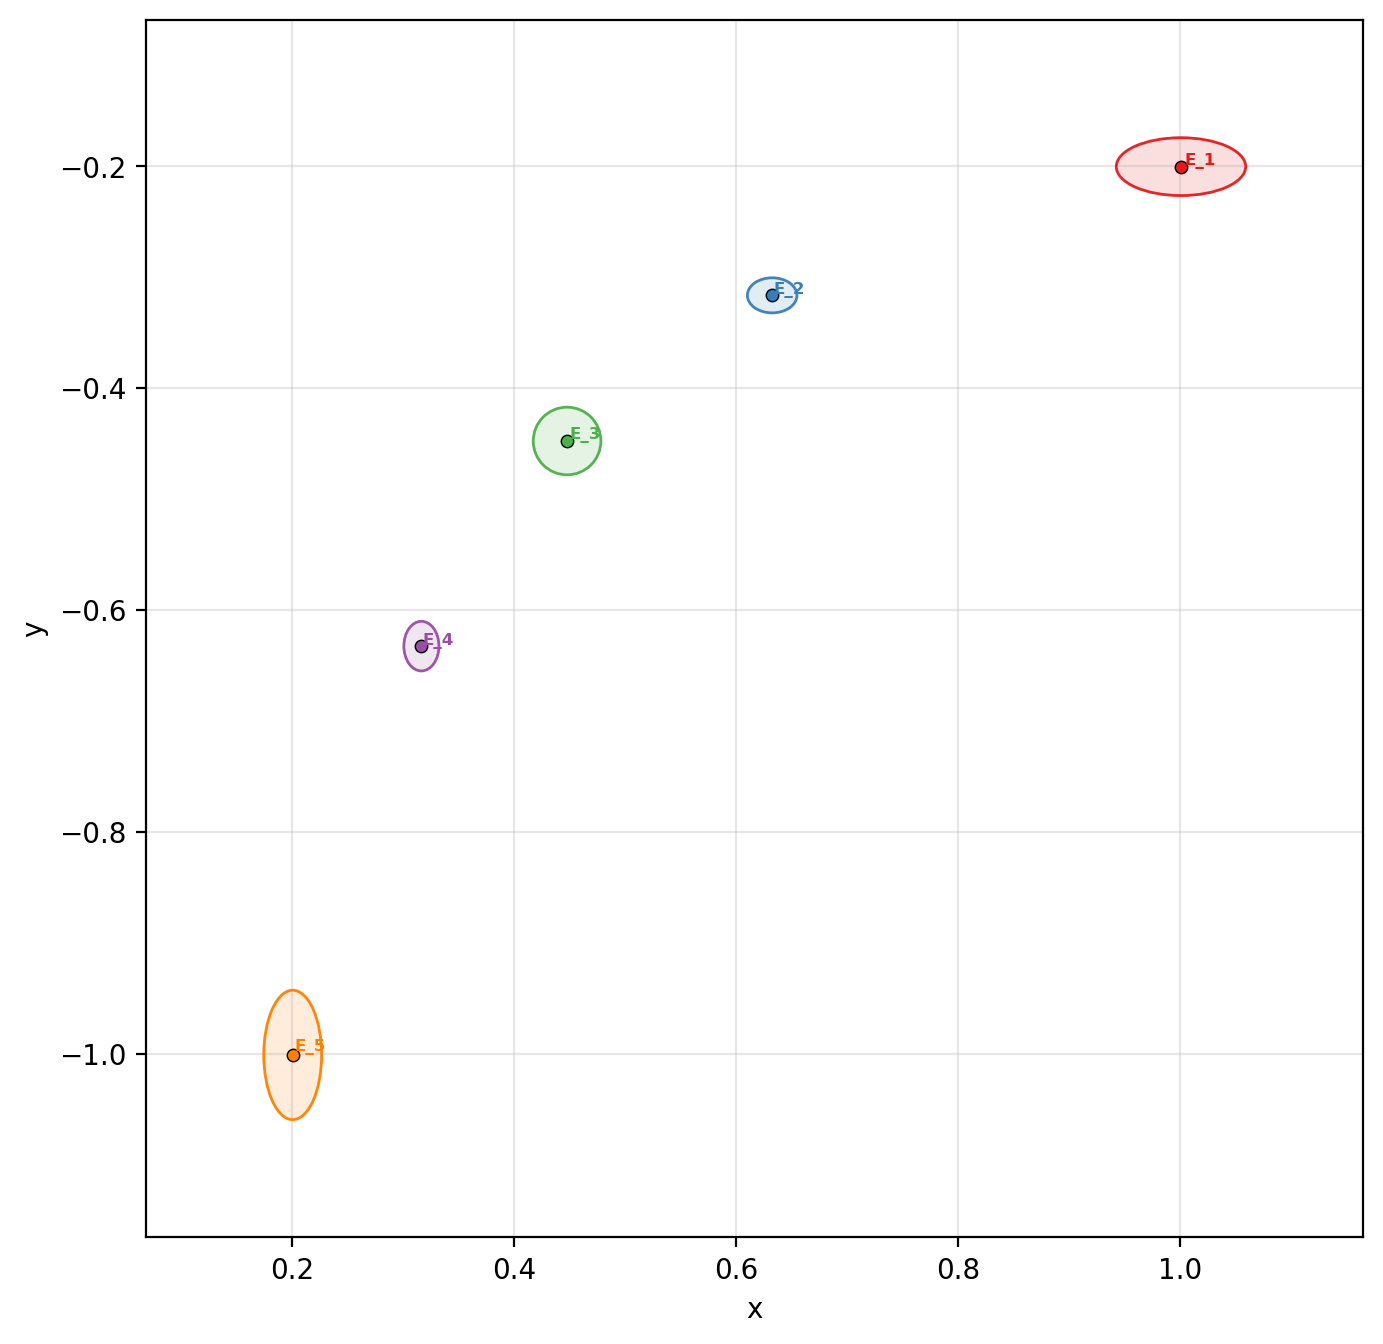

In [11]:
# pertubation
pertubed_list = myp_list
for i in range(len(myp_list)):
    if i % 2 == 0:
        pertubed_list[i] += 0.001
    else:
        pertubed_list[i] -= 0.001
Delta_per = max(compute_c_values(pertubed_list)) + 0.001
plot_partition_ellipses(pertubed_list, Delta_per)
plt.show()

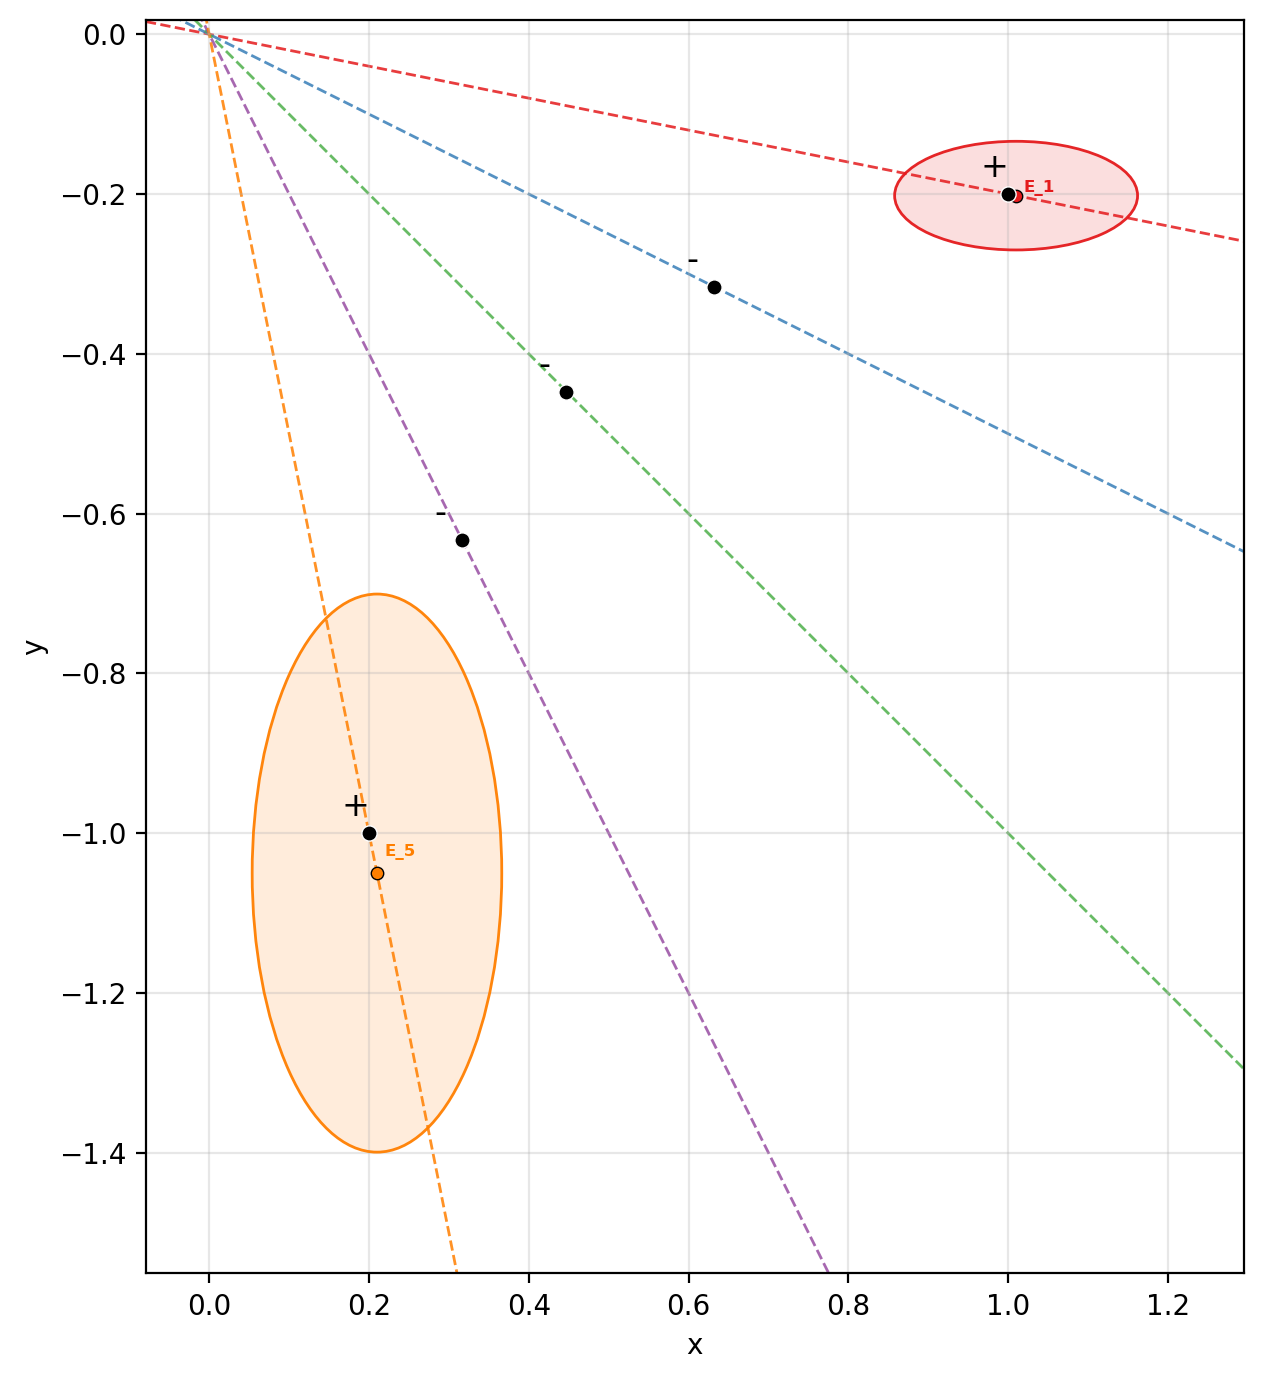

In [12]:
P = myp_list
points = [(mya_list[i], - ((i+1)/(len(myp_list)-(i+1)) * mya_list[i])) for i in range(len(mya_list))]

new_a = []
for i in range(len(mya_list)):
    a = mya_list[i] + (0.01 if (i == 0 or i == 4) else +0.0)
    new_a.append(a)
P_new = compute_p_from_a(new_a)
Delta = max(compute_c_values(P_new)) - 0.001
ax = plot_partition_ellipses(P_new, Delta)
ax1 = plot_partition_lines(P_new, ax=ax, linewidth=1.0, linestyle="--", alpha=0.85)
labels = ["+", "-", "-", "-", "+"]
for i in range(len(points)):
    ax1.scatter(points[i][0], points[i][1], color="black", s=30, edgecolors="white", linewidths=0.5, zorder=4)
    ax1.annotate(
        labels[i],                 # label text
        (points[i][0], points[i][1]),                  # point
        xytext=(-10, 6),           # small offset so text is not on top of marker
        textcoords="offset points",
        fontsize=12,
        color="black",
        zorder=5,
    )
plt.show()

In [13]:
print("C values for P_new:", compute_c_values(P_new))

C values for P_new: [1.0214213166516544, 1.0455413166516543, 1.0455413166516543, 1.0455413166516545, 0.9225413166516545]


d_1 = 0.001000,  d_2 = 0.000629,  d_3 = 0.001469
||P_1||^2 = 2.28825865
||P_2||^2 = 2.28825865
||P_3||^2 = 2.28825865


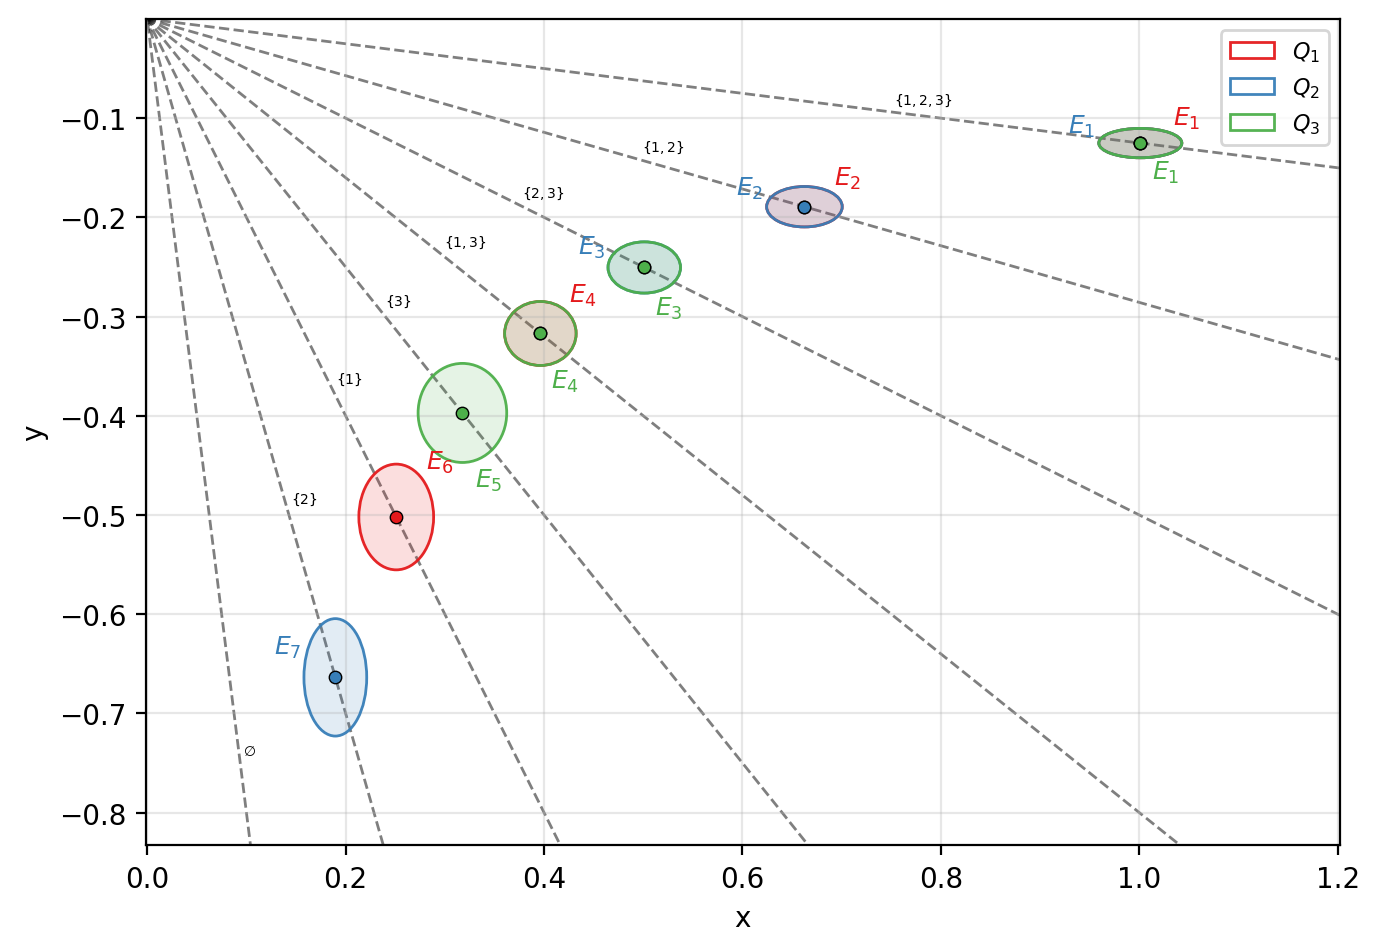

In [15]:
from scipy.optimize import brentq

# Build several partitions P_1, ..., P_m and show all their ellipses in one plot.
# Each P_i is constructed by slightly shifting the a-values along the line.

d = 0.001
a_values = compute_point_on_line(1.0, 9)
a_values2 = compute_point_on_line(0.75, 9)
more_points = [(a_values2[i], - ((i+1)/(len(a_values2)+1-(i+1)) * a_values2[i])) for i in range(len(a_values2))]

def norm_sq(P):
    return sum(p**2 for p in P)

def make_a1(d1):
    return [a_values[0] + d, a_values[1] + d, a_values[2], a_values[3] + d, a_values[4], a_values[5] + d1, a_values[6], a_values[7]]

def make_a2(d2):
    return [a_values[0] + d, a_values[1] + d, a_values[2] + d, a_values[3], a_values[4], a_values[5], a_values[6] + d2, a_values[7]]

def make_a3(d3):
    return [a_values[0] + d, a_values[1], a_values[2] + d, a_values[3] + d, a_values[4] + d3, a_values[5], a_values[6], a_values[7]]

# Fix d_1 and use its norm as the target
d_1 = 0.001
target = norm_sq(compute_p_from_a(make_a1(d_1)))

# Solve for d_2 and d_3 via bisection so that ||P_2||^2 = ||P_3||^2 = target
d_2 = brentq(lambda d2: norm_sq(compute_p_from_a(make_a2(d2))) - target, 1e-10, 10.0)
d_3 = brentq(lambda d3: norm_sq(compute_p_from_a(make_a3(d3))) - target, 1e-10, 10.0)

print(f"d_1 = {d_1:.6f},  d_2 = {d_2:.6f},  d_3 = {d_3:.6f}")
print(f"||P_1||^2 = {norm_sq(compute_p_from_a(make_a1(d_1))):.8f}")
print(f"||P_2||^2 = {norm_sq(compute_p_from_a(make_a2(d_2))):.8f}")
print(f"||P_3||^2 = {norm_sq(compute_p_from_a(make_a3(d_3))):.8f}")

a_1 = make_a1(d_1)
a_2 = make_a2(d_2)
a_3 = make_a3(d_3)

Q_1 = compute_p_from_a(a_1)
Q_2 = compute_p_from_a(a_2)
Q_3 = compute_p_from_a(a_3)

Delta_1 = max(compute_c_values(Q_1))
Delta_2 = max(compute_c_values(Q_2))
Delta_3 = max(compute_c_values(Q_3))
Delta = max(Delta_1, Delta_2, Delta_3) - d * 0.5

partitions = [[Q_1, Delta], [Q_2, Delta], [Q_3, Delta]]

ax = plot_multi_partition_ellipses(partitions)
ax = plot_partition_lines(Q_1, ax=ax, linewidth=1.0, linestyle="--", alpha=0.5, color="black")

labels = [
    r"$\{1,2,3\}$",
    r"$\{1,2\}$",
    r"$\{2,3\}$",
    r"$\{1,3\}$",
    r"$\{3\}$",
    r"$\{1\}$",
    r"$\{2\}$",
    r"$\emptyset$",
]
for i in range(len(more_points)):
    ax.scatter(more_points[i][0], more_points[i][1], color="black", s=0, edgecolors="white", linewidths=0.5, zorder=4)
    ax.annotate(
        labels[i],
        (more_points[i][0], more_points[i][1]),
        xytext=(1, 3),
        textcoords="offset points",
        fontsize=5,
        color="black",
        zorder=5,
    )

# Expand axis limits to ensure all scatter/annotation points are visible.
pt_xs = [p[0] for p in more_points]
pt_ys = [p[1] for p in more_points]
cur_xl = ax.get_xlim()
cur_yl = ax.get_ylim()
pad_x = 0.05 * (cur_xl[1] - cur_xl[0])
pad_y = 0.05 * (cur_yl[1] - cur_yl[0])
ax.set_xlim(min(cur_xl[0], min(pt_xs) - pad_x), max(cur_xl[1], max(pt_xs) + pad_x))
ax.set_ylim(min(cur_yl[0], min(pt_ys) - pad_y), max(cur_yl[1], max(pt_ys) + pad_y))

plt.show()
